**ফ্যাসেট প্লট (Facet Plot)** বা **FacetGrid** হলো ডেটা ভিজ্যুয়ালাইজেশনের এমন একটি চমৎকার কৌশল, যেখানে একটি বড় ডেটাসেটকে নির্দিষ্ট কোনো ক্যাটাগরির ওপর ভিত্তি করে ছোট ছোট একাধিক সাব-প্লটে (Sub-plot) ভাগ করে পাশাপাশি বা উপর-নিচ করে সাজানো হয়।

একে অনেক সময় **"Small Multiples"**-ও বলা হয়। আগের উত্তরে আপনি `relplot`-এর যে ভাগ করার ক্ষমতাটি দেখেছিলেন, সেটি মূলত এই ফ্যাসেট প্লটেরই কাজ।

### **কেন এটি এত জনপ্রিয়?**
ধরা যাক, আপনার কাছে একটি দোকানের গত ৫ দিনের বিক্রির ডেটা আছে, যেখানে ঢাকা এবং চট্টগ্রামের শাখায় ল্যাপটপ ও মোবাইলের বিক্রির হিসাব আছে। আপনি যদি এই সব ডেটা (২টি শহর × ২টি পণ্য = ৪টি লাইন) একটিমাত্র গ্রাফের ভেতরে আঁকেন, তবে গ্রাফটি খুব হিজিবিজি (Cluttered) হয়ে যাবে।

ফ্যাসেট প্লট এই সমস্যার সমাধান করে। এটি ডেটাকে এমনভাবে ভাগ করে দেয় যাতে প্রতিটি ক্যাটাগরির জন্য একটি করে ছোট এবং পরিষ্কার গ্রাফ তৈরি হয়, কিন্তু **সবগুলো গ্রাফের X-অক্ষ এবং Y-অক্ষের স্কেল একদম সমান থাকে**, যাতে আপনি সহজেই একটির সাথে আরেকটির তুলনা করতে পারেন।

### **কীভাবে কাজ করে (Seaborn-এর ক্ষেত্রে)?**
Seaborn-এ `relplot` বা `catplot` ব্যবহার করার সময় আপনি দুটি মূল প্যারামিটার দিয়ে এই ফ্যাসেটিং করতে পারেন:
১. **`col` (Column):** এটি গ্রাফগুলোকে পাশাপাশি (বাম থেকে ডানে) সাজায়।
২. **`row` (Row):** এটি গ্রাফগুলোকে উপর-নিচ করে সাজায়।


### **এক নজরে ফ্যাসেট প্লটের সুবিধা:**
* **তুলনা করা সহজ:** যেহেতু সবগুলো সাব-প্লটের স্কেল একই থাকে, তাই আপনি খুব দ্রুত বুঝতে পারবেন কোন শহরে বা কোন পণ্যের বিক্রি বেশি।
* **প্যাটার্ন খোঁজা:** কোনো নির্দিষ্ট গ্রুপের মধ্যে কোনো অদ্ভুত আচরণ বা ট্রেন্ড আছে কি না, তা সহজেই চোখে পড়ে।
* **পরিষ্কার ভিউ:** একটি গ্রাফে অনেক লাইন দিয়ে জগাখিচুড়ি না বানিয়ে, পরিপাটি করে ডেটা উপস্থাপন করা যায়।

In [1]:
# import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
student = pd.read_csv('/content/drive/MyDrive/Dataset/sns_data.csv')
student

,student_id,class_level,subject,study_hours,test_score,week,attendance_rate,gender,hostel,Tshirt_size
0,1,Freshman,Math,5,78,1,90,Male,True,30
1,2,Freshman,Science,3,65,1,80,Female,False,20
2,3,Freshman,History,4,70,1,85,Male,True,20
3,4,Freshman,Language,2,60,1,75,Female,True,40
4,5,Sophomore,Math,6,82,1,92,Male,True,20
...,...,...,...,...,...,...,...,...,...,...
90,91,Junior,Math,7,85,6,94,Male,False,30
91,92,Junior,Science,6,78,6,88,Female,False,30
92,93,Junior,History,5,72,6,84,Male,False,10
93,94,Junior,Language,4,68,6,80,Female,False,30


# **Facet Plot Using Seaborn**

In [3]:
student.columns

Index(['student_id', 'class_level', 'subject', 'study_hours', 'test_score',
       'week', 'attendance_rate', 'gender', 'hostel', 'Tshirt_size'],
      dtype='object')

<Axes: xlabel='study_hours', ylabel='test_score'>

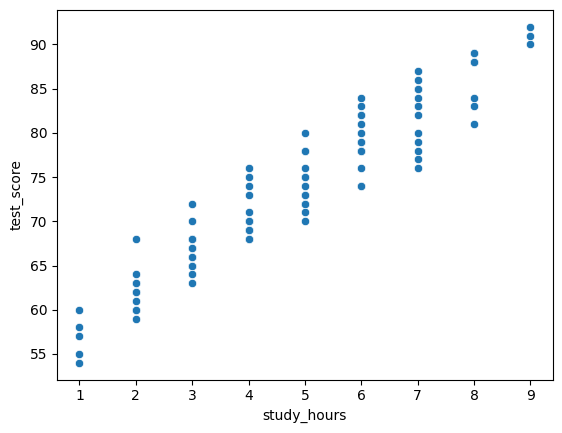

In [4]:
sns.scatterplot(data=student, x="study_hours", y="test_score")

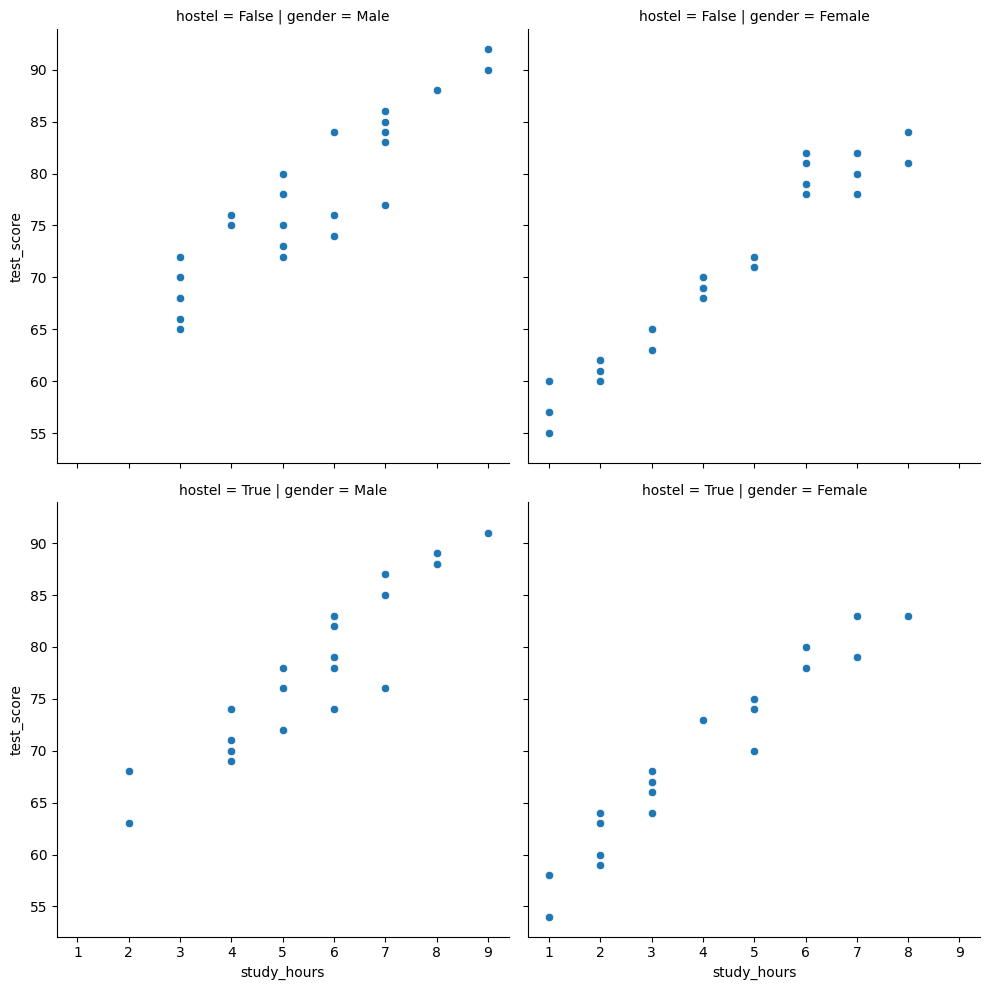

In [11]:
sns.relplot(data=student, x="study_hours", y="test_score", kind="scatter",col="gender", row="hostel")

### **কোডের ব্যবচ্ছেদ:**

`sns.relplot(data=student, x="study_hours", y="test_score", kind="scatter", col="gender", row="hostel")`

১. **বেসিক সেটআপ (`data`, `x`, `y`):**
* এটি `student` ডেটাসেট থেকে ডেটা নিচ্ছে।
* সবগুলোর গ্রাফের X-অক্ষে `study_hours` (পড়ার সময়) এবং Y-অক্ষে `test_score` (পরীক্ষার নম্বর) বসিয়েছে।

২. **চার্টের ধরন (`kind="scatter"`):**
* এখানে `kind="scatter"` ব্যবহার করায় এটি লাইন না এঁকে বিন্দু (dots) দিয়ে ডেটাগুলো দেখিয়েছে।

৩. **আসল ম্যাজিক (`col` এবং `row`):**
* **`col="gender"`:** এটি নির্দেশ দিয়েছে গ্রাফটিকে জেন্ডার বা লিঙ্গের ভিত্তিতে ডান-বামে (কলামে) ভাগ করতে।
    * **বাম দিকের কলাম:** `gender = Male` (শুধু ছাত্রদের ডেটা)।
    * **ডান দিকের কলাম:** `gender = Female` (শুধু ছাত্রীদের ডেটা)।
* **`row="hostel"`:** এটি নির্দেশ দিয়েছে গ্রাফটিকে হোস্টেলে থাকার ওপর ভিত্তি করে উপর-নিচে (রো-তে) ভাগ করতে।
    * **উপরের সারি (Row):** `hostel = False` (যারা হোস্টেলে থাকে না)।
    * **নিচের সারি (Row):** `hostel = True` (যারা হোস্টেলে থাকে)।

---

### **এই ভাগের ফলে ৪টি আলাদা গ্রুপ তৈরি হয়েছে:**

ছবিটির দিকে তাকালে দেখবেন প্রতিটি গ্রাফের ওপরে ছোট করে লেখা আছে সেটি কোন গ্রুপের ডেটা:

* **উপরে বামে:** ছাত্র, যারা হোস্টেলে থাকে না (`hostel = False | gender = Male`)
* **উপরে ডানে:** ছাত্রী, যারা হোস্টেলে থাকে না (`hostel = False | gender = Female`)
* **নিচে বামে:** ছাত্র, যারা হোস্টেলে থাকে (`hostel = True | gender = Male`)
* **নিচে ডানে:** ছাত্রী, যারা হোস্টেলে থাকে (`hostel = True | gender = Female`)

**এর সুবিধা কী?**
এইভাবে ভাগ করার ফলে আপনি খুব সহজেই বিশ্লেষণ করতে পারবেন যে, হোস্টেলে থাকলে বা না থাকলে ছেলে ও মেয়েদের পড়াশোনা এবং রেজাল্টের প্যাটার্নে কোনো পার্থক্য তৈরি হয় কি না, আর সেটিও কোনো জগাখিচুড়ি গ্রাফ তৈরি না করেই!


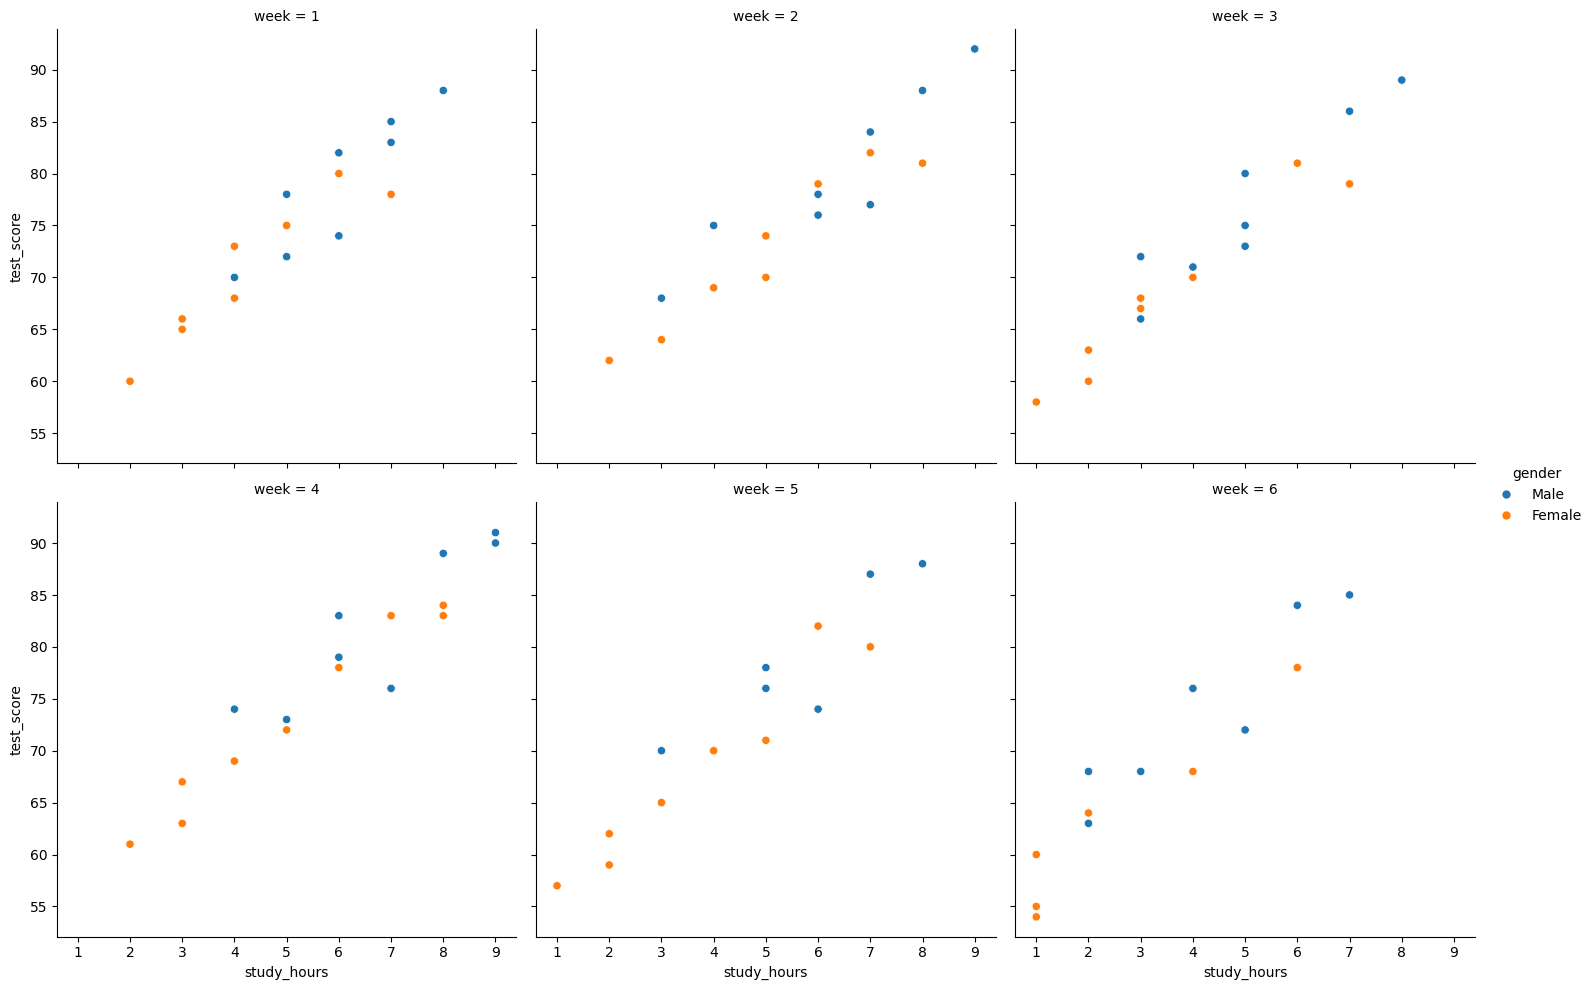

In [13]:
sns.relplot(data=student, x="study_hours", y="test_score", kind="scatter", col="week", hue="gender", col_wrap=3)

col_wrap=3: সবগুলো সপ্তাহের গ্রাফ এক লাইনে না সাজিয়ে, প্রতি লাইনে সর্বোচ্চ ৩টি করে গ্রাফ সাজিয়ে সুন্দর একটি গ্রিড (Grid) তৈরি করবে।